# Self supervised learning autoencoder

Un Autoencoder es una arquitectura de red neuronal diseñada para aprender representaciones eficientes de los datos. A diferencia de un modelo de clasificación tradicional que busca predecir una etiqueta, el objetivo del autoencoder es aprender a reconstruir su propia entrada.

Para lograrlo, la red no puede simplemente memorizar los datos; se la obliga a pasar la información a través de un "cuello de botella" de menor dimensionalidad. Esto fuerza al modelo a descartar lo irrelevante y descubrir la estructura matemática y los patrones fundamentales de la señal.

## Arquitectura Principal

El modelo se divide en dos etapas que se entrenan en conjunto:

Encoder (Codificador): Es la primera mitad de la red. Toma la señal original y, mediante capas convolucionales y reducciones de dimensionalidad (Pooling), comprime los datos. El resultado de esta etapa es el espacio latente, una representación densa y resumida que contiene solo la información más crítica de la señal.

Decoder (Decodificador): Es la segunda mitad. Toma ese espacio latente comprimido y utiliza operaciones inversas para intentar reconstruir la señal original con la mayor fidelidad posible.

Durante el entrenamiento, el modelo ajusta sus pesos minimizando el error entre la señal que entró al encoder y la que salió del decoder.

## Filtrado y Eliminación de Ruido (Denoising)

Los autoencoders son excepcionalmente buenos para limpiar señales de sensores gracias a la naturaleza de su cuello de botella.

El ruido en un sensor (como vibraciones espurias o estática) es inherentemente aleatorio y caótico. Por el contrario, los eventos físicos reales tienen estructuras fuertes y repetitivas. Como el espacio latente es pequeño, la red no tiene la capacidad suficiente para codificar el ruido aleatorio. Se ve obligada a priorizar y retener solo los patrones dominantes. Como resultado, al reconstruir la señal en el decoder, el ruido simplemente se pierde, devolviendo una curva mucho más limpia y suave.

## Extracción de Características e Independencia Temporal

Una de las mayores utilidades del encoder es su capacidad para preparar los datos antes de alimentar una red clasificadora (como una CNN).

Analizar series temporales crudas es complejo porque el tiempo es rígido. Un mismo evento físico (como un impacto) puede ocurrir en la muestra 50 en una medición y en la muestra 200 en otra. Para una red tradicional, estos son escenarios completamente distintos.

El uso de un encoder convolucional resuelve este problema:

* Las capas convolucionales buscan formas geométricas específicas (picos, escalones, curvas) sin importar dónde estén.

* Las capas de Pooling comprimen el eje del tiempo, generando invarianza temporal.

Al llegar al espacio latente, la dimensión temporal estricta casi ha desaparecido. La señal se ha transformado en un vector de características abstractas (features). Este vector ya no representa una línea de tiempo punto por punto, sino que describe los conceptos presentes en la señal (por ejemplo: "hay un impacto brusco seguido de inmovilidad").

Al desconectar el decoder y utilizar solo el encoder preentrenado, se le puede entregar este resumen de alta calidad a un modelo clasificador, facilitando enormemente su trabajo y mejorando la precisión.

## Estructura propuesta

En este caso se propone una arquitectura de encoder que permita extraer 3 señales de acelerometros en los 3 ejes (X,Y,Z), con una frecuencia de muestre de 40Hz y un tiempo total de 13seg, formando un total de 520 datos por canal. Estos datos temporales de los sensores son procesados en primer instancia por una capa convolucional de 3x3, luego una capa que reduce su tamaño con el metodo max pooling y repitiendo esta estructura en 4 etapas. El resultado es un output de 61 muestras  x 128 canales. 

La siguiente imagen muestra mas en detalle el esquema del encoder:

![image.png](imgs/image.png)

In [1]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import layers, losses
from tensorflow.keras import Model

import csv
import glob
import os

from models import *
from utils import *

I0000 00:00:1779328773.276993   34695 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779328773.298692   34695 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
get_columnas_csv(path='outputs_FallAI_Dataset', file = 'Event_FallAIIDDataSet_*.txt')

['TimeStamp(s)',
 'AccX',
 'AccY',
 'AccZ',
 'GyrX',
 'GyrY',
 'GyrZ',
 'MagX',
 'MagY',
 'MagZ',
 'Bar',
 'Temp']

In [ ]:
data = extraer_datos_csv(path='./Datasets/outputs_FallAI_Dataset', file = 'Event_FallAIIDDataSet_*.txt', sensors= ['AccX','AccY','AccZ'])
data.shape

(2515, 520, 3)

In [4]:
escalador = dataScaler() ## Fitea los datos y guarda sus coef.

datos_normalizados = escalador.escalar_datos(data)

# Agrega la dimension para coincidir con el input
datos_entrenamiento = np.expand_dims(datos_normalizados, axis=-1)

print(f"Shape datos_entrenamiento {datos_entrenamiento.shape}")

# obtengo datos de prueba y de entrenamiento
data_train, data_test = train_test_split(datos_entrenamiento, test_size=0.2, random_state=21)

print(f"Shape data_train {data_train.shape}")
print(f"Shape data_test {data_test.shape}")

Shape datos_entrenamiento (2515, 520, 3, 1)
Shape data_train (2012, 520, 3, 1)
Shape data_test (503, 520, 3, 1)


In [5]:
autoencoder = Autoencoder()

In [6]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [7]:
autoencoder.fit(data_train, data_train,
                epochs=75,
                shuffle=True,
                validation_data=(data_test, data_test))

Epoch 1/75
 4/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.0452  

E0000 00:00:1779328777.421184   34695 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.4944 - val_loss: 0.2471
Epoch 2/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1963 - val_loss: 0.1483
Epoch 3/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1412 - val_loss: 0.1229
Epoch 4/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1225 - val_loss: 0.1079
Epoch 5/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1137 - val_loss: 0.0965
Epoch 6/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1052 - val_loss: 0.0899
Epoch 7/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0991 - val_loss: 0.0860
Epoch 8/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0963 - val_loss: 0.0840
Epoch 9/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0923 - val_loss: 0.0798
Epoch 10/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0892 - val_loss: 0.0783
Epoch 11/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0887 - val_loss: 0.0771
Epoch 12/75
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0852 - val_l

In [14]:
test  = data_test[4:5, : , : ] # Tomo una muestra del data_test

res = autoencoder.call(x = test) # La estimo con el autoencoder

test = test[0, : , :, 0]
print(f"El Shape de test es {test.shape}")

res = res[0,:,:,0]
print(f"El Shape de res es {res.shape}")

El Shape de test es (520, 3)
El Shape de res es (520, 3)


/tmp/ipykernel_34695/1387839865.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


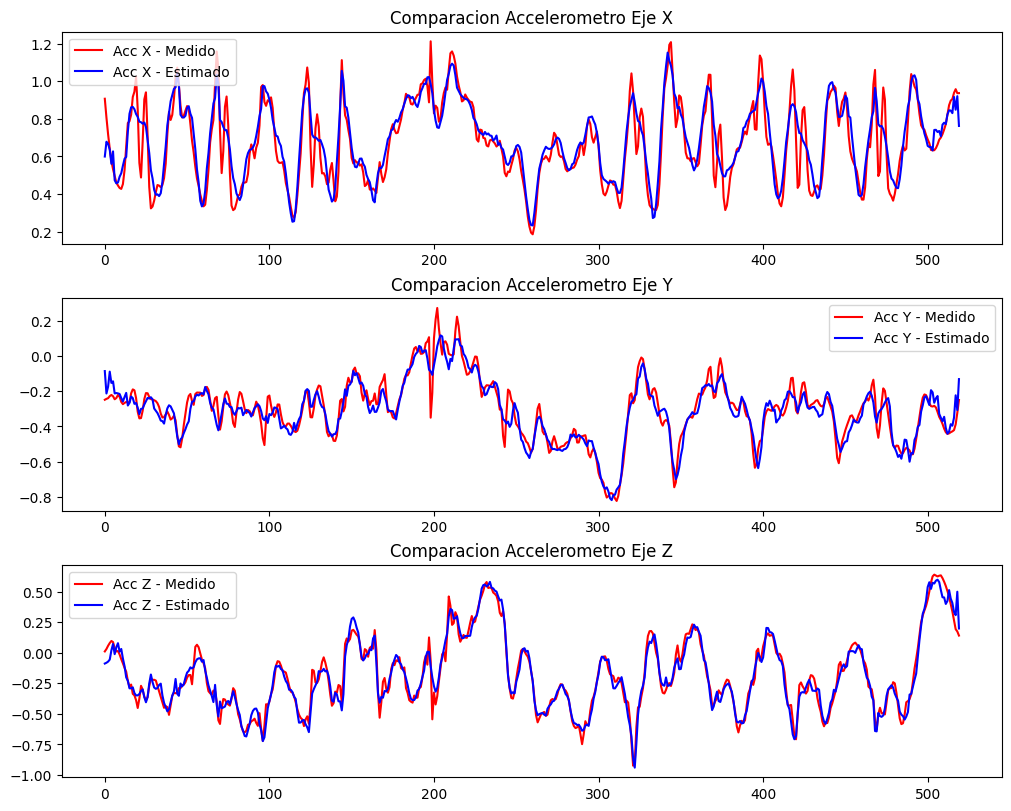

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)
       
axs[0].plot(test[:,0], label='Acc X - Medido', color='red') 
axs[1].plot(test[:,1], label='Acc Y - Medido', color='red') 
axs[2].plot(test[:,2], label='Acc Z - Medido', color='red') 

axs[0].plot(res[:,0], label='Acc X - Estimado', color='blue') 
axs[1].plot(res[:,1], label='Acc Y - Estimado', color='blue') 
axs[2].plot(res[:,2], label='Acc Z - Estimado', color='blue') 

    
axs[0].set_title('Comparacion Accelerometro Eje X')
axs[0].legend()
axs[1].set_title('Comparacion Accelerometro Eje Y')
axs[1].legend()
axs[2].set_title('Comparacion Accelerometro Eje Z')
axs[2].legend()

fig.show()

In [18]:
# Extraigo los pesos del encoder y decoder

for capa in autoencoder.encoder.layers:
    # Verificamos si la capa es una convolución 2D
    if isinstance(capa, tf.keras.layers.Conv2D):
        # get_weights() devuelve una lista con 2 elementos: [pesos, sesgos]
        pesos_capa = capa.get_weights()
        
        # Validamos que la capa tenga pesos (algunas podrían no tener si no están construidas)
        if len(pesos_capa) > 0:
            filtros = pesos_capa[0]
            sesgos = pesos_capa[1]
            
            print(f"Capa: {capa.name}")
            print(f" - Forma de los filtros: {filtros.shape}")
            print(f" - Forma de los sesgos: {sesgos.shape}\n")
            
            # Si quisieras ver los valores exactos del primer filtro (índice 0):
            #print(filtros[:, :, :, :])



Capa: CONV1_16
 - Forma de los filtros: (3, 3, 1, 16)
 - Forma de los sesgos: (16,)

Capa: CONV2_32
 - Forma de los filtros: (3, 1, 16, 32)
 - Forma de los sesgos: (32,)

Capa: CONV3_64
 - Forma de los filtros: (3, 1, 32, 64)
 - Forma de los sesgos: (64,)

Capa: CONV4_128
 - Forma de los filtros: (3, 1, 64, 128)
 - Forma de los sesgos: (128,)



In [20]:
# Suponiendo que tu modelo se llama 'autoencoder' o 'self.encoder'
ruta_archivo_encoder = 'coeficientes_encoder.csv'
ruta_archivo_decoder = 'coeficientes_decoder.csv'

with open(ruta_archivo_encoder, 'w', newline='') as f:
    writer = csv.writer(f)
    
    for capa in autoencoder.encoder.layers:
        if isinstance(capa, tf.keras.layers.Conv2D):
            pesos = capa.get_weights()
            if len(pesos) > 0:
                filtros, sesgos = pesos
                
                # Fila 1: Filtros -> [Nombre, Tipo, dim1, dim2, dim3, dim4, valores...]
                forma_filtros = list(filtros.shape)
                datos_filtros = filtros.flatten().tolist()
                writer.writerow([capa.name, 'filtros'] + forma_filtros + datos_filtros)
                
                # Fila 2: Sesgos -> [Nombre, Tipo, dim1, valores...]
                forma_sesgos = list(sesgos.shape)
                datos_sesgos = sesgos.flatten().tolist()
                writer.writerow([capa.name, 'sesgos'] + forma_sesgos + datos_sesgos)

print(f"¡Coeficientes guardados exitosamente en {ruta_archivo_encoder}!")

with open(ruta_archivo_decoder, 'w', newline='') as f:
    writer = csv.writer(f)
    
    for capa in autoencoder.decoder.layers:
        if isinstance(capa, tf.keras.layers.Conv2DTranspose):
            pesos = capa.get_weights()
            if len(pesos) > 0:
                filtros, sesgos = pesos
                
                # Fila 1: Filtros -> [Nombre, Tipo, dim1, dim2, dim3, dim4, valores...]
                forma_filtros = list(filtros.shape)
                datos_filtros = filtros.flatten().tolist()
                writer.writerow([capa.name, 'filtros'] + forma_filtros + datos_filtros)
                
                # Fila 2: Sesgos -> [Nombre, Tipo, dim1, valores...]
                forma_sesgos = list(sesgos.shape)
                datos_sesgos = sesgos.flatten().tolist()
                writer.writerow([capa.name, 'sesgos'] + forma_sesgos + datos_sesgos)

print(f"¡Coeficientes guardados exitosamente en {ruta_archivo_decoder}!")

¡Coeficientes guardados exitosamente en coeficientes_encoder.csv!
¡Coeficientes guardados exitosamente en coeficientes_decoder.csv!
